# 10 - MLB Pitch-Mix + Bullpen Availability Model Lab

This notebook is a leakage-safe modeling lab for the newest feature upgrade:

- Pitcher pitch-mix vs opponent offense by pitch group
- Starter pitch-type quality by pitch group
- Bullpen workload / availability pressure
- Existing Statcast, batted-ball, starter, team, ELO, and bullpen features

The notebook intentionally keeps outcome columns like `home_score`, `away_score`, `diff_score`, and `home_margin` out of the model feature list.

In [32]:
from pathlib import Path
from datetime import timedelta
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import ParameterSampler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print('XGBoost unavailable:', repr(e))

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print('LightGBM unavailable:', repr(e))

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42
TARGET_COL = 'target_home_win'

In [33]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'mlb_game_features.parquet'
assert FEATURES_PATH.exists(), f'Missing feature file: {FEATURES_PATH}'

features = pd.read_parquet(FEATURES_PATH)
features['official_date'] = pd.to_datetime(features['official_date'], errors='coerce')
if 'game_datetime_utc' in features.columns:
    features['game_datetime_utc'] = pd.to_datetime(features['game_datetime_utc'], utc=True, errors='coerce')

completed = features[features[TARGET_COL].notna()].copy()
completed[TARGET_COL] = completed[TARGET_COL].astype(int)

unresolved = features[features[TARGET_COL].isna()].copy()

print('Rows:', len(features))
print('Columns:', len(features.columns))
print('Completed rows:', len(completed))
print('Unresolved rows:', len(unresolved))
print('All date range:', features['official_date'].min(), 'to', features['official_date'].max())
print('Completed date range:', completed['official_date'].min(), 'to', completed['official_date'].max())

Rows: 9293
Columns: 4887
Completed rows: 9089
Unresolved rows: 204
All date range: 2022-08-02 00:00:00 to 2026-09-22 00:00:00
Completed date range: 2022-08-02 00:00:00 to 2026-06-02 00:00:00


## True scoring candidates
`target_home_win.isna()` means unresolved, not necessarily upcoming. This cell filters true scoring candidates by date/status.

In [34]:
AS_OF_DATE = pd.Timestamp.today(tz='America/Chicago').date()
DAYS_FORWARD = 14

unresolved = unresolved.copy()
unresolved['official_date_dt'] = pd.to_datetime(unresolved['official_date']).dt.date

start_date = AS_OF_DATE
end_date = AS_OF_DATE + timedelta(days=DAYS_FORWARD)

date_mask = (unresolved['official_date_dt'] >= start_date) & (unresolved['official_date_dt'] <= end_date)
status_mask = pd.Series(True, index=unresolved.index)

if 'abstract_state' in unresolved.columns:
    status_mask &= unresolved['abstract_state'].astype(str).str.lower().isin(['preview', 'live'])

if 'detailed_state' in unresolved.columns:
    bad_states = 'postponed|cancelled|canceled|suspended|final|completed'
    status_mask &= ~unresolved['detailed_state'].astype(str).str.lower().str.contains(bad_states, na=False)

scoring_candidates = unresolved[date_mask & status_mask].copy()

print('AS_OF_DATE:', AS_OF_DATE)
print('Scoring candidates:', len(scoring_candidates))
if len(scoring_candidates):
    print('Scoring candidate range:', scoring_candidates['official_date'].min(), 'to', scoring_candidates['official_date'].max())
    display(scoring_candidates[[c for c in ['game_pk','official_date','game_datetime_utc','away_team_name','home_team_name','abstract_state','detailed_state'] if c in scoring_candidates.columns]].head(30))

AS_OF_DATE: 2026-06-03
Scoring candidates: 199
Scoring candidate range: 2026-06-03 00:00:00 to 2026-06-17 00:00:00


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state
9094,822727,2026-06-03,2026-06-03 17:05:00+00:00,Miami Marlins,Washington Nationals,Live,In Progress
9095,822973,2026-06-03,2026-06-03 17:10:00+00:00,Detroit Tigers,Tampa Bay Rays,Live,In Progress
9096,823701,2026-06-03,2026-06-03 17:40:00+00:00,Chicago White Sox,Minnesota Twins,Live,In Progress
9097,823130,2026-06-03,2026-06-03 19:40:00+00:00,New York Mets,Seattle Mariners,Preview,Pre-Game
9098,823456,2026-06-03,2026-06-03 22:40:00+00:00,San Diego Padres,Philadelphia Phillies,Preview,Scheduled
9099,824755,2026-06-03,2026-06-03 22:45:00+00:00,Baltimore Orioles,Boston Red Sox,Preview,Pre-Game
9100,823540,2026-06-03,2026-06-03 23:05:00+00:00,Cleveland Guardians,New York Yankees,Preview,Scheduled
9101,824509,2026-06-03,2026-06-03 23:10:00+00:00,Kansas City Royals,Cincinnati Reds,Preview,Pre-Game
9102,824917,2026-06-03,2026-06-03 23:15:00+00:00,Toronto Blue Jays,Atlanta Braves,Preview,Scheduled
9103,823780,2026-06-03,2026-06-03 23:40:00+00:00,San Francisco Giants,Milwaukee Brewers,Preview,Scheduled


## Modeling window
Use all available data or set `MIN_TRAIN_DATE` to restrict training. Keeping 2022 rows is okay if you want more sample size.

In [35]:
MIN_TRAIN_DATE = '2022-08-01'  # set to '2023-01-01' if you want strict 2023+ only
completed_i = completed[completed['official_date'] >= pd.Timestamp(MIN_TRAIN_DATE)].copy()
print('Training completed rows:', len(completed_i))
print('Training date range:', completed_i['official_date'].min(), 'to', completed_i['official_date'].max())
print('Target rate:', completed_i[TARGET_COL].mean())

Training completed rows: 9089
Training date range: 2022-08-02 00:00:00 to 2026-06-02 00:00:00
Target rate: 0.5305314115964352


## Leakage-safe feature selection
These cells remove known postgame/outcome columns and identifiers before any model sees the data.

In [36]:
LEAKY_COLS_EXACT = {
    'home_score',
    'away_score',
    'diff_score',
    'home_margin',
    TARGET_COL,
}

metadata_cols = {
    'game_pk',
    'run_id',
    'scored_at_utc',
    'official_date',
    'official_date_dt',
    'game_datetime_utc',
    'home_team_name',
    'away_team_name',
    'home_team_id',
    'away_team_id',
    'venue_name',
    'abstract_state',
    'detailed_state',
}

rolling_tokens = ['_last1', '_last3', '_last5', '_last10', '_last20', '_last40', '_season_to_date', '_pre']

def is_probably_leaky_feature(col: str) -> bool:
    c = col.lower()
    if c in LEAKY_COLS_EXACT:
        return True
    hard_patterns = ['winner', 'winning', 'losing', 'final', 'result', 'outcome', 'actual', 'post_']
    if any(p in c for p in hard_patterns):
        return True
    if c.endswith('_id') or c in metadata_cols:
        return True
    # Same-game raw boxscore fields are leakage unless they are explicitly rolling/pregame.
    if c.startswith(('home_team_box_', 'away_team_box_', 'diff_team_box_')):
        if not any(tok in c for tok in rolling_tokens):
            return True
    return False

candidate_feature_cols = [
    c for c in completed_i.columns
    if c not in metadata_cols
    and c != TARGET_COL
    and pd.api.types.is_numeric_dtype(completed_i[c])
]

clean_feature_cols = [c for c in candidate_feature_cols if not is_probably_leaky_feature(c)]

print('Candidate feature count:', len(candidate_feature_cols))
print('Clean feature count:', len(clean_feature_cols))
removed_features = sorted(set(candidate_feature_cols) - set(clean_feature_cols))
display(pd.Series(removed_features, name='removed_features').head(150))

Candidate feature count: 4864
Clean feature count: 4829


0                        away_score
1           away_team_box_bb_per_ab
2       away_team_box_games_to_date
3           away_team_box_hr_per_ab
4            away_team_box_k_per_ab
5         away_team_box_lob_per_run
6         away_team_box_sb_attempts
7     away_team_box_sb_success_rate
8                 away_team_box_xbh
9         away_team_box_xbh_per_hit
10                       diff_score
11          diff_team_box_bb_per_ab
12      diff_team_box_games_to_date
13          diff_team_box_hr_per_ab
14           diff_team_box_k_per_ab
15        diff_team_box_lob_per_run
16        diff_team_box_sb_attempts
17    diff_team_box_sb_success_rate
18                diff_team_box_xbh
19        diff_team_box_xbh_per_hit
20                     diff_team_id
21                      home_margin
22                       home_score
23          home_team_box_bb_per_ab
24      home_team_box_games_to_date
25          home_team_box_hr_per_ab
26           home_team_box_k_per_ab
27        home_team_box_lob_

In [37]:
# Single-feature AUC leakage check. Anything near 1.0 is suspicious.
single_feature_auc = []
y_audit = completed_i[TARGET_COL].astype(int)

for c in clean_feature_cols:
    s = completed_i[c]
    tmp = pd.DataFrame({'x': s, 'y': y_audit}).dropna()
    if tmp['x'].nunique() < 2 or tmp['y'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(tmp['y'], tmp['x'])
        auc = max(auc, 1 - auc)
        single_feature_auc.append((c, auc, len(tmp), tmp['x'].nunique()))
    except Exception:
        pass

single_feature_auc = pd.DataFrame(single_feature_auc, columns=['feature','single_feature_auc','n','n_unique']).sort_values('single_feature_auc', ascending=False)
display(single_feature_auc.head(75))

leakage_alerts = single_feature_auc[single_feature_auc['single_feature_auc'] >= 0.90]
if len(leakage_alerts):
    print('WARNING: possible leakage features still present')
    display(leakage_alerts.head(50))
else:
    print('No single-feature AUC >= 0.90 after leakage filter.')

,feature,single_feature_auc,n,n_unique
4790,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.000000,6,6
4791,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.000000,6,6
4786,diff_starter_pitchtype_other_sc_pitch_type_avg...,1.000000,6,6
4785,diff_starter_pitchtype_other_sc_pitch_type_avg...,1.000000,6,6
4792,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.000000,6,6
...,...,...,...,...
641,diff_team_vs_hand_obp_last10,0.558163,9049,2810
3319,home_starter_pitchtype_other_sc_pitch_type_har...,0.558050,149,23
915,diff_team_off_sc_woba_season_to_date,0.556462,9059,9059
639,diff_team_vs_hand_ops_last20,0.556151,9049,6561


,feature,single_feature_auc,n,n_unique
4790,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.0,6,6
4791,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.0,6,6
4786,diff_starter_pitchtype_other_sc_pitch_type_avg...,1.0,6,6
4785,diff_starter_pitchtype_other_sc_pitch_type_avg...,1.0,6,6
4792,diff_starter_pitchtype_other_sc_pitch_type_p90...,1.0,6,6
4807,diff_starter_pitchtype_other_sc_pitch_type_har...,0.9,6,3


## New feature-family diagnostics

In [38]:
search_terms = [
    "pitchmix",
    "pitch_mix",
    "pitch_type",
    "pitchtype",
    "coarse_pitch",
    "arsenal",
    "bullpen_avail",
    "availability",
    "fatigue",
    "pitches_sum",
    "pitches_last",
]

for term in search_terms:
    cols = [c for c in features.columns if term in c.lower()]
    print(f"\n{term}: {len(cols)}")
    print(cols[:80])


pitchmix: 288
['home_pitchmix_matchup_off_sc_pitch_type_woba_season_to_date', 'away_pitchmix_matchup_off_sc_pitch_type_woba_season_to_date', 'diff_pitchmix_matchup_off_sc_pitch_type_woba_season_to_date', 'home_pitchmix_matchup_off_sc_pitch_type_xwoba_contact_season_to_date', 'away_pitchmix_matchup_off_sc_pitch_type_xwoba_contact_season_to_date', 'diff_pitchmix_matchup_off_sc_pitch_type_xwoba_contact_season_to_date', 'home_pitchmix_matchup_off_sc_pitch_type_avg_ev_season_to_date', 'away_pitchmix_matchup_off_sc_pitch_type_avg_ev_season_to_date', 'diff_pitchmix_matchup_off_sc_pitch_type_avg_ev_season_to_date', 'home_pitchmix_matchup_off_sc_pitch_type_p90_ev_season_to_date', 'away_pitchmix_matchup_off_sc_pitch_type_p90_ev_season_to_date', 'diff_pitchmix_matchup_off_sc_pitch_type_p90_ev_season_to_date', 'home_pitchmix_matchup_off_sc_pitch_type_avg_batted_ball_distance_season_to_date', 'away_pitchmix_matchup_off_sc_pitch_type_avg_batted_ball_distance_season_to_date', 'diff_pitchmix_matchup_

In [39]:
def cols_containing(tokens, base_cols=None):
    base_cols = clean_feature_cols if base_cols is None else base_cols
    toks = [t.lower() for t in tokens]
    return [c for c in base_cols if any(t in c.lower() for t in toks)]

feature_families = {
    'all_clean': clean_feature_cols,
    'statcast_only': cols_containing(['statcast', '_sc_', 'batted_ball', 'distance', 'avg_ev']),
    'team_statcast': cols_containing(['team_off_sc_', 'team_vs_hand_sc_']),
    'starter_statcast': cols_containing(['starter_statcast_sc_']),
    'bullpen_quality': cols_containing(['bullpen_sc_', 'sc_bullpen_']),
    'bullpen_availability': cols_containing(['bullpen_avail_', 'availability_pressure', 'days_since_last_game', 'pitches_sum_last', 'high_usage_games']),
    'pitch_type_raw': cols_containing(['pitchtype_']),
    'pitchmix_matchup': cols_containing(['pitchmix_matchup', 'starter_pitchmix_allowed']),
    'pitchmix_plus_bullpen': [],
}
feature_families['pitchmix_plus_bullpen'] = sorted(set(feature_families['pitchmix_matchup'] + feature_families['bullpen_availability'] + feature_families['bullpen_quality']))
feature_families['statcast_pitchmix_bullpen'] = sorted(set(feature_families['statcast_only'] + feature_families['pitchmix_matchup'] + feature_families['bullpen_availability']))

family_summary = pd.DataFrame([
    {'feature_family': k, 'feature_count': len(v)}
    for k, v in feature_families.items()
]).sort_values('feature_count', ascending=False)
display(family_summary)

for fam in ['bullpen_availability', 'pitchmix_matchup', 'pitch_type_raw']:
    print('', fam, 'sample:')
    display(pd.Series(feature_families[fam]).head(50))

,feature_family,feature_count
0,all_clean,4829
1,statcast_only,4179
9,statcast_pitchmix_bullpen,4179
6,pitch_type_raw,2280
8,pitchmix_plus_bullpen,699
2,team_statcast,675
3,starter_statcast,525
4,bullpen_quality,411
7,pitchmix_matchup,288
5,bullpen_availability,81


 bullpen_availability sample:


0     home_bullpen_avail_sc_bullpen_days_since_last_...
1       home_bullpen_avail_sc_bullpen_pitches_sum_last1
2      home_bullpen_avail_sc_bullpen_pitches_mean_last1
3     home_bullpen_avail_sc_bullpen_pitchers_used_su...
4            home_bullpen_avail_sc_bullpen_pa_sum_last1
5     home_bullpen_avail_sc_bullpen_high_usage_games...
6     home_bullpen_avail_sc_bullpen_very_high_usage_...
7       home_bullpen_avail_sc_bullpen_pitches_sum_last3
8      home_bullpen_avail_sc_bullpen_pitches_mean_last3
9     home_bullpen_avail_sc_bullpen_pitchers_used_su...
10           home_bullpen_avail_sc_bullpen_pa_sum_last3
11    home_bullpen_avail_sc_bullpen_high_usage_games...
12    home_bullpen_avail_sc_bullpen_very_high_usage_...
13      home_bullpen_avail_sc_bullpen_pitches_sum_last5
14     home_bullpen_avail_sc_bullpen_pitches_mean_last5
15    home_bullpen_avail_sc_bullpen_pitchers_used_su...
16           home_bullpen_avail_sc_bullpen_pa_sum_last5
17    home_bullpen_avail_sc_bullpen_high_usage_g

 pitchmix_matchup sample:


0     home_pitchmix_matchup_off_sc_pitch_type_woba_s...
1     away_pitchmix_matchup_off_sc_pitch_type_woba_s...
2     diff_pitchmix_matchup_off_sc_pitch_type_woba_s...
3     home_pitchmix_matchup_off_sc_pitch_type_xwoba_...
4     away_pitchmix_matchup_off_sc_pitch_type_xwoba_...
5     diff_pitchmix_matchup_off_sc_pitch_type_xwoba_...
6     home_pitchmix_matchup_off_sc_pitch_type_avg_ev...
7     away_pitchmix_matchup_off_sc_pitch_type_avg_ev...
8     diff_pitchmix_matchup_off_sc_pitch_type_avg_ev...
9     home_pitchmix_matchup_off_sc_pitch_type_p90_ev...
10    away_pitchmix_matchup_off_sc_pitch_type_p90_ev...
11    diff_pitchmix_matchup_off_sc_pitch_type_p90_ev...
12    home_pitchmix_matchup_off_sc_pitch_type_avg_ba...
13    away_pitchmix_matchup_off_sc_pitch_type_avg_ba...
14    diff_pitchmix_matchup_off_sc_pitch_type_avg_ba...
15    home_pitchmix_matchup_off_sc_pitch_type_p90_ba...
16    away_pitchmix_matchup_off_sc_pitch_type_p90_ba...
17    diff_pitchmix_matchup_off_sc_pitch_type_p9

 pitch_type_raw sample:


0     home_team_pitchtype_fastball_sc_pitch_type_pa_...
1     home_team_pitchtype_fastball_sc_pitch_type_pa_...
2     home_team_pitchtype_fastball_sc_pitch_type_pa_...
3     home_team_pitchtype_fastball_sc_pitch_type_pa_...
4     home_team_pitchtype_fastball_sc_pitch_type_pa_...
5     home_team_pitchtype_fastball_sc_pitch_type_pit...
6     home_team_pitchtype_fastball_sc_pitch_type_pit...
7     home_team_pitchtype_fastball_sc_pitch_type_pit...
8     home_team_pitchtype_fastball_sc_pitch_type_pit...
9     home_team_pitchtype_fastball_sc_pitch_type_pit...
10    home_team_pitchtype_fastball_sc_pitch_type_bbe...
11    home_team_pitchtype_fastball_sc_pitch_type_bbe...
12    home_team_pitchtype_fastball_sc_pitch_type_bbe...
13    home_team_pitchtype_fastball_sc_pitch_type_bbe...
14    home_team_pitchtype_fastball_sc_pitch_type_bbe...
15    home_team_pitchtype_fastball_sc_pitch_type_wob...
16    home_team_pitchtype_fastball_sc_pitch_type_wob...
17    home_team_pitchtype_fastball_sc_pitch_type

## Missingness handling

In [53]:
DROP_IF_MISSING_GT = 0.40
MANUAL_DROP_PATTERNS = ['sb_success_rate']

missing_pct = completed_i[clean_feature_cols].isna().mean().sort_values(ascending=False)
high_missing_cols = missing_pct[missing_pct > DROP_IF_MISSING_GT].index.tolist()
manual_drop_cols = [c for c in clean_feature_cols if any(p in c.lower() for p in MANUAL_DROP_PATTERNS)]

model_drop_cols = sorted(set(high_missing_cols + manual_drop_cols))
model_base_cols = [c for c in clean_feature_cols if c not in model_drop_cols]

print('Dropping high/manual missing/noisy columns:', len(model_drop_cols))
display(pd.Series(model_drop_cols, name='dropped_cols').head(150))
print('Model base feature count:', len(model_base_cols))

Dropping high/manual missing/noisy columns: 408


0      away_starter_pitchtype_other_sc_pitch_type_avg...
1      away_starter_pitchtype_other_sc_pitch_type_avg...
2      away_starter_pitchtype_other_sc_pitch_type_avg...
3      away_starter_pitchtype_other_sc_pitch_type_avg...
4      away_starter_pitchtype_other_sc_pitch_type_avg...
                             ...                        
145    diff_starter_pitchtype_other_sc_pitch_type_bar...
146    diff_starter_pitchtype_other_sc_pitch_type_bar...
147    diff_starter_pitchtype_other_sc_pitch_type_bar...
148    diff_starter_pitchtype_other_sc_pitch_type_bb_...
149    diff_starter_pitchtype_other_sc_pitch_type_bb_...
Name: dropped_cols, Length: 150, dtype: object

Model base feature count: 4421


## Chronological split and baseline

In [55]:
def chronological_split(df: pd.DataFrame, test_frac: float = 0.20):
    df = df.sort_values(['official_date', 'game_datetime_utc', 'game_pk']).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = chronological_split(completed_i, test_frac=0.20)
y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)

baseline_train_rate = y_train.mean()
baseline_probs = np.repeat(baseline_train_rate, len(y_test))

baseline_metrics = {
    'model_name': 'constant_train_home_rate',
    'feature_count': 0,
    'n_test': len(y_test),
    'avg_pred': float(baseline_probs.mean()),
    'actual_rate': float(y_test.mean()),
    'log_loss': float(log_loss(y_test, baseline_probs)),
    'brier': float(brier_score_loss(y_test, baseline_probs)),
    'roc_auc': 0.5,
    'accuracy_50pct': float(accuracy_score(y_test, baseline_probs >= 0.5)),
    'suspicious_metric': False,
}

display(pd.DataFrame([baseline_metrics]))
print('Train:', len(train_df), train_df['official_date'].min(), 'to', train_df['official_date'].max())
print('Test:', len(test_df), test_df['official_date'].min(), 'to', test_df['official_date'].max())

,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,constant_train_home_rate,0,1818,0.530876,0.529153,0.691452,0.249153,0.5,0.529153,False


Train: 7271 2022-08-02 00:00:00 to 2025-07-23 00:00:00
Test: 1818 2025-07-23 00:00:00 to 2026-06-02 00:00:00


## Model comparison across new feature families

In [56]:
def make_models():
    models = {
        'random_forest': RandomForestClassifier(
            n_estimators=500, min_samples_leaf=25, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
        ),
        'extra_trees': ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=15, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
        ),
        'hist_gbdt': HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.03, max_leaf_nodes=15, l2_regularization=0.1, random_state=RANDOM_STATE
        ),
    }
    if XGBOOST_AVAILABLE:
        models['xgboost'] = XGBClassifier(
            objective='binary:logistic', eval_metric='logloss', tree_method='hist',
            n_estimators=350, max_depth=2, learning_rate=0.03, min_child_weight=10,
            subsample=0.85, colsample_bytree=0.75, reg_alpha=0.1, reg_lambda=3.0,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    if LIGHTGBM_AVAILABLE:
        models['lightgbm'] = LGBMClassifier(
            n_estimators=350, learning_rate=0.03, num_leaves=15, min_child_samples=50,
            subsample=0.85, colsample_bytree=0.75, reg_alpha=0.1, reg_lambda=3.0,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    return models


def evaluate_model(model_name, model, cols):
    cols = [c for c in cols if c in model_base_cols and c in train_df.columns]
    if len(cols) == 0:
        return None, None, None

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('model', model),
    ])
    pipe.fit(train_df[cols], y_train)
    p = pipe.predict_proba(test_df[cols])[:, 1]
    metrics = {
        'model_name': model_name,
        'feature_count': len(cols),
        'n_test': len(y_test),
        'avg_pred': float(np.mean(p)),
        'actual_rate': float(np.mean(y_test)),
        'log_loss': float(log_loss(y_test, p)),
        'brier': float(brier_score_loss(y_test, p)),
        'roc_auc': float(roc_auc_score(y_test, p)),
        'accuracy_50pct': float(accuracy_score(y_test, p >= 0.5)),
    }
    metrics['suspicious_metric'] = bool(metrics['roc_auc'] > 0.90 or metrics['accuracy_50pct'] > 0.85 or metrics['log_loss'] < 0.20)
    return pipe, p, metrics

# Only run family/model combinations that have useful feature counts.
selected_families = [
    'statcast_only',
    'bullpen_availability',
    'pitchmix_matchup',
    'pitchmix_plus_bullpen',
    'statcast_pitchmix_bullpen',
    'all_clean',
]

results = [baseline_metrics]
fitted_models = {}
preds_by_name = {}
cols_by_name = {}

for fam in selected_families:
    fam_cols = [c for c in feature_families.get(fam, []) if c in model_base_cols]
    if len(fam_cols) < 5:
        print(f'Skipping {fam}: only {len(fam_cols)} features')
        continue
    for alg_name, alg in make_models().items():
        name = f'{fam}__{alg_name}'
        pipe, p, metrics = evaluate_model(name, alg, fam_cols)
        if metrics is None:
            continue
        results.append(metrics)
        fitted_models[name] = (pipe, fam_cols)
        preds_by_name[name] = p
        cols_by_name[name] = fam_cols

results_df = pd.DataFrame(results).sort_values(['log_loss', 'brier', 'roc_auc'], ascending=[True, True, False]).reset_index(drop=True)
display(results_df)

C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature nam

,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,statcast_pitchmix_bullpen__xgboost,3786,1818,0.545318,0.529153,0.684359,0.245648,0.569378,0.556656,False
1,statcast_only__xgboost,3786,1818,0.542720,0.529153,0.684631,0.245782,0.567568,0.560506,False
2,all_clean__random_forest,4421,1818,0.535278,0.529153,0.684748,0.245866,0.559446,0.565457,False
3,statcast_only__random_forest,3786,1818,0.534197,0.529153,0.684756,0.245863,0.557949,0.563806,False
4,pitchmix_plus_bullpen__random_forest,699,1818,0.532632,0.529153,0.684864,0.245906,0.562002,0.562156,False
5,pitchmix_plus_bullpen__extra_trees,699,1818,0.531249,0.529153,0.685339,0.246125,0.565311,0.554455,False
6,statcast_pitchmix_bullpen__random_forest,3786,1818,0.535569,0.529153,0.685674,0.246310,0.554928,0.545655,False
7,all_clean__extra_trees,4421,1818,0.536372,0.529153,0.685753,0.246339,0.556873,0.555556,False
8,statcast_pitchmix_bullpen__extra_trees,3786,1818,0.535856,0.529153,0.686384,0.246655,0.551789,0.546755,False
9,all_clean__xgboost,4421,1818,0.542139,0.529153,0.686804,0.246756,0.563002,0.555556,False


## Top-model calibration

Top models: ['statcast_pitchmix_bullpen__xgboost', 'statcast_only__xgboost', 'all_clean__random_forest']


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,statcast_pitchmix_bullpen__xgboost,3786,1818,0.545318,0.529153,0.684359,0.245648,0.569378,0.556656,False
1,statcast_only__xgboost,3786,1818,0.542720,0.529153,0.684631,0.245782,0.567568,0.560506,False
2,all_clean__random_forest,4421,1818,0.535278,0.529153,0.684748,0.245866,0.559446,0.565457,False


,model_name,bucket,games,avg_pred_prob,actual_home_win_rate,calibration_error
0,statcast_pitchmix_bullpen__xgboost,"(-0.001, 0.35]",7,0.335144,0.571429,0.236284
1,statcast_pitchmix_bullpen__xgboost,"(0.35, 0.4]",46,0.381920,0.347826,-0.034094
2,statcast_pitchmix_bullpen__xgboost,"(0.4, 0.45]",142,0.428622,0.436620,0.007998
3,statcast_pitchmix_bullpen__xgboost,"(0.45, 0.5]",357,0.477637,0.473389,-0.004247
4,statcast_pitchmix_bullpen__xgboost,"(0.5, 0.55]",393,0.524419,0.536896,0.012477
5,statcast_pitchmix_bullpen__xgboost,"(0.55, 0.6]",419,0.573563,0.548926,-0.024636
6,statcast_pitchmix_bullpen__xgboost,"(0.6, 0.65]",280,0.621917,0.542857,-0.079060
7,statcast_pitchmix_bullpen__xgboost,"(0.65, 0.7]",120,0.671510,0.650000,-0.021510
8,statcast_pitchmix_bullpen__xgboost,"(0.7, 1.0]",54,0.721389,0.740741,0.019351
9,statcast_only__xgboost,"(-0.001, 0.35]",10,0.333445,0.300000,-0.033445


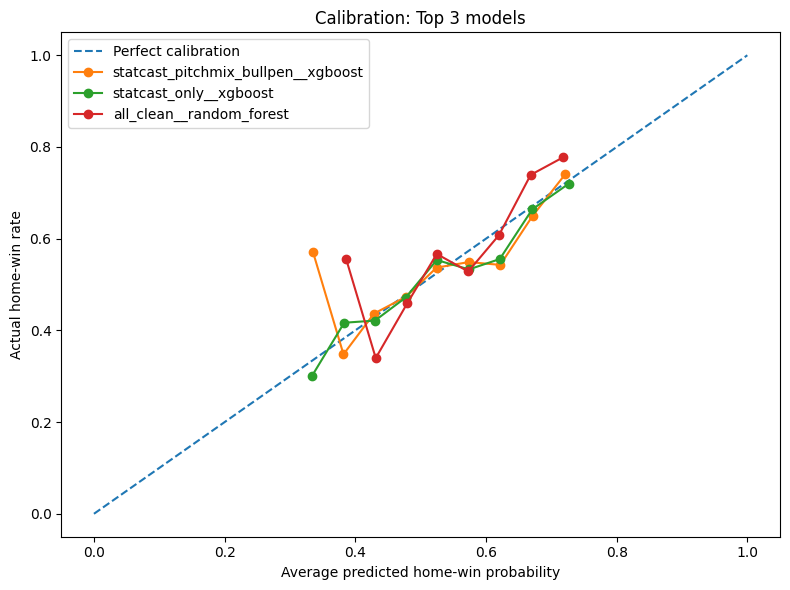

In [57]:
eligible = results_df[(~results_df['suspicious_metric']) & (results_df['model_name'] != 'constant_train_home_rate') & (results_df['model_name'].isin(fitted_models.keys()))].copy()
eligible = eligible.sort_values(['log_loss', 'brier', 'roc_auc'], ascending=[True, True, False])
top_model_names = eligible['model_name'].head(3).tolist()
print('Top models:', top_model_names)
display(eligible.head(3))

bins = [0, .35, .40, .45, .50, .55, .60, .65, .70, 1.0]
calib_frames = []
for name in top_model_names:
    p = preds_by_name[name]
    tmp = pd.DataFrame({'model_name': name, 'p': p, 'y': y_test.values})
    tmp['bucket'] = pd.cut(tmp['p'], bins=bins, include_lowest=True)
    tab = tmp.groupby(['model_name','bucket'], observed=False).agg(
        games=('y','size'), avg_pred_prob=('p','mean'), actual_home_win_rate=('y','mean')
    ).reset_index()
    tab['calibration_error'] = tab['actual_home_win_rate'] - tab['avg_pred_prob']
    calib_frames.append(tab)
calib_table_all = pd.concat(calib_frames, ignore_index=True) if calib_frames else pd.DataFrame()
display(calib_table_all)

plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1], linestyle='--', label='Perfect calibration')
for name in top_model_names:
    plot_df = calib_table_all[(calib_table_all['model_name'].eq(name)) & (calib_table_all['games'] > 0)].dropna()
    plt.plot(plot_df['avg_pred_prob'], plot_df['actual_home_win_rate'], marker='o', label=name)
plt.xlabel('Average predicted home-win probability')
plt.ylabel('Actual home-win rate')
plt.title('Calibration: Top 3 models')
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
import pandas as pd
import numpy as np

TARGET_COL = "target_home_win"

# -------------------------------------------------------------------
# 1. Ensure completed_i exists
# -------------------------------------------------------------------
if "completed_i" not in globals():
    completed_i = features[features[TARGET_COL].notna()].copy()
    completed_i["official_date"] = pd.to_datetime(completed_i["official_date"])
    completed_i[TARGET_COL] = completed_i[TARGET_COL].astype(int)

    # Optional training start filter
    MIN_TRAIN_DATE = "2023-01-01"
    completed_i = completed_i[completed_i["official_date"] >= MIN_TRAIN_DATE].copy()

# -------------------------------------------------------------------
# 2. Recreate clean_feature_cols if needed
# -------------------------------------------------------------------
LEAKY_COLS_EXACT = {
    "home_score",
    "away_score",
    "diff_score",
    "home_margin",
    "target_home_win",
}

metadata_cols = {
    "game_pk",
    "run_id",
    "scored_at_utc",
    "official_date",
    "official_date_dt",
    "game_datetime_utc",
    "home_team_name",
    "away_team_name",
    "home_team_id",
    "away_team_id",
    "venue_name",
    "abstract_state",
    "detailed_state",
}

def is_probably_leaky_feature(col: str) -> bool:
    c = col.lower()

    if c in LEAKY_COLS_EXACT:
        return True

    hard_patterns = [
        "winner",
        "winning",
        "losing",
        "final",
        "result",
        "outcome",
        "actual",
        "post_",
    ]

    if any(p in c for p in hard_patterns):
        return True

    if c.endswith("_id") or c in metadata_cols:
        return True

    return False


candidate_feature_cols = [
    c for c in completed_i.columns
    if c not in metadata_cols
    and c != TARGET_COL
    and pd.api.types.is_numeric_dtype(completed_i[c])
]

clean_feature_cols = [
    c for c in candidate_feature_cols
    if not is_probably_leaky_feature(c)
]

print("Candidate feature count:", len(candidate_feature_cols))
print("Clean feature count:", len(clean_feature_cols))

# -------------------------------------------------------------------
# 3. Build feature families from scratch
# -------------------------------------------------------------------
def cols_containing_any(cols, terms):
    terms = [t.lower() for t in terms]
    return [
        c for c in cols
        if any(t in c.lower() for t in terms)
    ]

all_numeric_cols = [
    c for c in clean_feature_cols
    if c in completed_i.columns
    and pd.api.types.is_numeric_dtype(completed_i[c])
]

PITCHMIX_TERMS = [
    "pitchmix",
    "pitch_mix",
    "pitch_type",
    "pitchtype",
    "coarse_pitch",
    "arsenal",
    "matchup",
]

BULLPEN_AVAIL_TERMS = [
    "bullpen_avail",
    "availability",
    "fatigue",
    "bullpen_pitches_last",
    "sc_bullpen_pitches_last",
    "diff_bullpen_pitches_last",
    "diff_sc_bullpen_pitches_last",
    "relievers_used",
    "back_to_back",
]

BULLPEN_QUALITY_TERMS = [
    "bullpen_sc",
    "diff_bullpen_sc",
    "home_bullpen_sc",
    "away_bullpen_sc",
    "sc_bullpen",
]

STATCAST_TERMS = [
    "statcast",
    "_sc_",
    "sc_",
    "batted_ball",
    "avg_ev",
    "distance",
    "hard_hit",
    "barrel",
]

def contains_any(col, terms):
    c = col.lower()
    return any(t in c for t in terms)

statcast_cols = cols_containing_any(all_numeric_cols, STATCAST_TERMS)

pitchmix_cols = cols_containing_any(all_numeric_cols, PITCHMIX_TERMS)

bullpen_availability_cols = cols_containing_any(all_numeric_cols, BULLPEN_AVAIL_TERMS)

bullpen_quality_cols = cols_containing_any(all_numeric_cols, BULLPEN_QUALITY_TERMS)

# Old Statcast without explicit pitchmix / bullpen availability
old_statcast_cols = [
    c for c in statcast_cols
    if not contains_any(c, PITCHMIX_TERMS + BULLPEN_AVAIL_TERMS)
]

team_statcast_cols = cols_containing_any(
    all_numeric_cols,
    [
        "team_off_sc",
        "team_vs_hand_sc",
        "diff_team_off_sc",
        "diff_team_vs_hand_sc",
    ],
)

starter_statcast_cols = cols_containing_any(
    all_numeric_cols,
    [
        "starter_statcast",
        "starter_sc",
        "diff_starter_statcast",
    ],
)

batted_ball_cols = cols_containing_any(
    all_numeric_cols,
    [
        "batted_ball",
        "avg_ev",
        "max_ev",
        "distance",
        "hard_hit",
        "barrel",
    ],
)

feature_sets = {
    "old_statcast_no_pitchmix_bullpen": sorted(set(old_statcast_cols)),
    "true_pitchmix": sorted(set(pitchmix_cols)),
    "true_bullpen_availability": sorted(set(bullpen_availability_cols)),
    "bullpen_quality": sorted(set(bullpen_quality_cols)),
    "pitchmix_plus_bullpen": sorted(set(pitchmix_cols + bullpen_quality_cols + bullpen_availability_cols)),
    "old_statcast_plus_pitchmix_bullpen": sorted(set(old_statcast_cols + pitchmix_cols + bullpen_availability_cols)),
    "team_statcast": sorted(set(team_statcast_cols)),
    "starter_statcast": sorted(set(starter_statcast_cols)),
    "batted_ball_only": sorted(set(batted_ball_cols)),
    "all_clean": sorted(set(all_numeric_cols)),
}

feature_family_summary = pd.DataFrame(
    [
        {"feature_family": k, "feature_count": len(v)}
        for k, v in feature_sets.items()
    ]
).sort_values("feature_count", ascending=False)

display(feature_family_summary)

for family in [
    "old_statcast_no_pitchmix_bullpen",
    "true_pitchmix",
    "true_bullpen_availability",
    "pitchmix_plus_bullpen",
    "old_statcast_plus_pitchmix_bullpen",
]:
    print("\n" + "=" * 90)
    print(family, len(feature_sets[family]))
    print(feature_sets[family][:80])

Candidate feature count: 4864
Clean feature count: 4856


,feature_family,feature_count
9,all_clean,4856
5,old_statcast_plus_pitchmix_bullpen,4191
4,pitchmix_plus_bullpen,3006
1,true_pitchmix,2583
0,old_statcast_no_pitchmix_bullpen,1503
8,batted_ball_only,1371
6,team_statcast,675
7,starter_statcast,525
3,bullpen_quality,411
2,true_bullpen_availability,105



old_statcast_no_pitchmix_bullpen 1503
['away_bullpen_sc_avg_batted_ball_distance_allowed_last1', 'away_bullpen_sc_avg_batted_ball_distance_allowed_last10', 'away_bullpen_sc_avg_batted_ball_distance_allowed_last3', 'away_bullpen_sc_avg_batted_ball_distance_allowed_last5', 'away_bullpen_sc_avg_batted_ball_distance_allowed_season_to_date', 'away_bullpen_sc_avg_batted_ball_ev_allowed_last1', 'away_bullpen_sc_avg_batted_ball_ev_allowed_last10', 'away_bullpen_sc_avg_batted_ball_ev_allowed_last3', 'away_bullpen_sc_avg_batted_ball_ev_allowed_last5', 'away_bullpen_sc_avg_batted_ball_ev_allowed_season_to_date', 'away_bullpen_sc_avg_ev_allowed_last1', 'away_bullpen_sc_avg_ev_allowed_last10', 'away_bullpen_sc_avg_ev_allowed_last3', 'away_bullpen_sc_avg_ev_allowed_last5', 'away_bullpen_sc_avg_ev_allowed_season_to_date', 'away_bullpen_sc_barrel_rate_allowed_last1', 'away_bullpen_sc_barrel_rate_allowed_last10', 'away_bullpen_sc_barrel_rate_allowed_last3', 'away_bullpen_sc_barrel_rate_allowed_last5',

## Optional XGBoost tuning for the best new family

In [ ]:
RUN_XGB_TUNING = False  # flip to True when you want to spend time tuning
TUNE_FAMILY = 'statcast_pitchmix_bullpen'

if RUN_XGB_TUNING:
    assert XGBOOST_AVAILABLE, 'XGBoost unavailable.'
    tune_cols = [c for c in feature_families[TUNE_FAMILY] if c in model_base_cols and c in train_df.columns]
    print('Tuning family:', TUNE_FAMILY, 'features:', len(tune_cols))

    # Split current train into train/validation; keep test untouched.
    train_inner, val_inner = chronological_split(train_df, test_frac=0.20)
    y_train_inner = train_inner[TARGET_COL].astype(int)
    y_val_inner = val_inner[TARGET_COL].astype(int)

    imp = SimpleImputer(strategy='median', add_indicator=True)
    X_train_inner = imp.fit_transform(train_inner[tune_cols])
    X_val_inner = imp.transform(val_inner[tune_cols])
    X_test_tune = imp.transform(test_df[tune_cols])

    param_space = {
        'max_depth': [2, 3, 4],
        'learning_rate': [0.01, 0.02, 0.03, 0.05],
        'min_child_weight': [5, 10, 20, 40],
        'subsample': [0.65, 0.75, 0.85, 0.95],
        'colsample_bytree': [0.50, 0.65, 0.80, 0.95],
        'gamma': [0.0, 0.25, 0.5, 1.0],
        'reg_alpha': [0.0, 0.05, 0.1, 0.5, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    }
    samples = list(ParameterSampler(param_space, n_iter=35, random_state=RANDOM_STATE))
    tuning_rows = []
    trained_trials = {}

    for i, params in enumerate(samples, start=1):
        model = XGBClassifier(
            objective='binary:logistic', eval_metric='logloss', tree_method='hist',
            n_estimators=2500, early_stopping_rounds=75, random_state=RANDOM_STATE, n_jobs=-1,
            **params
        )
        model.fit(X_train_inner, y_train_inner, eval_set=[(X_train_inner, y_train_inner), (X_val_inner, y_val_inner)], verbose=False)
        p_val = model.predict_proba(X_val_inner)[:,1]
        tuning_rows.append({
            'trial': i,
            **params,
            'best_iteration': getattr(model, 'best_iteration', np.nan),
            'val_log_loss': log_loss(y_val_inner, p_val),
            'val_brier': brier_score_loss(y_val_inner, p_val),
            'val_auc': roc_auc_score(y_val_inner, p_val),
        })
        trained_trials[i] = model

    tuning_df = pd.DataFrame(tuning_rows).sort_values(['val_log_loss','val_brier','val_auc'], ascending=[True, True, False])
    display(tuning_df.head(15))

    best_trial = int(tuning_df.iloc[0]['trial'])
    best_model = trained_trials[best_trial]
    evals = best_model.evals_result()
    plt.figure(figsize=(9,5))
    plt.plot(evals['validation_0']['logloss'], label='Train log loss')
    plt.plot(evals['validation_1']['logloss'], label='Validation log loss')
    plt.axvline(best_model.best_iteration, linestyle='--', label=f'Best iteration: {best_model.best_iteration}')
    plt.xlabel('Boosting round')
    plt.ylabel('Log loss')
    plt.title('XGBoost overfitting curve')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Set RUN_XGB_TUNING=True to run the tuning section.')

## Export champion model bundle
Only set `APPROVE_EXPORT=True` after reviewing metrics, calibration, and leakage checks.

In [ ]:
APPROVE_EXPORT = False
CHAMPION_NAME = top_model_names[0] if top_model_names else None

if APPROVE_EXPORT:
    import json
    import joblib
    from datetime import datetime, timezone

    assert CHAMPION_NAME in fitted_models, f'Champion not fitted: {CHAMPION_NAME}'
    champion_model, champion_cols = fitted_models[CHAMPION_NAME]
    p = preds_by_name[CHAMPION_NAME]

    model_dir = PROJECT_ROOT / 'models'
    model_dir.mkdir(exist_ok=True)

    bundle = {
        'model_name': CHAMPION_NAME,
        'model': champion_model,
        'feature_cols': champion_cols,
        'target_col': TARGET_COL,
        'created_at_utc': datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ'),
    }
    joblib.dump(bundle, model_dir / 'mlb_moneyline_champion.joblib')

    meta = {
        'model_name': CHAMPION_NAME,
        'feature_count': len(champion_cols),
        'test_log_loss': float(log_loss(y_test, p)),
        'test_brier': float(brier_score_loss(y_test, p)),
        'test_auc': float(roc_auc_score(y_test, p)),
        'test_accuracy_50pct': float(accuracy_score(y_test, p >= 0.5)),
        'train_min_date': str(train_df['official_date'].min()),
        'train_max_date': str(train_df['official_date'].max()),
        'test_min_date': str(test_df['official_date'].min()),
        'test_max_date': str(test_df['official_date'].max()),
    }
    with open(model_dir / 'mlb_moneyline_champion_metadata.json', 'w') as f:
        json.dump(meta, f, indent=2)

    print('Exported:', model_dir / 'mlb_moneyline_champion.joblib')
    print('Exported:', model_dir / 'mlb_moneyline_champion_metadata.json')
else:
    print('APPROVE_EXPORT is False. Review results first.')
    print('Suggested champion:', CHAMPION_NAME)